In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_avg_all = pd.read_csv('/Users/suthardr/Desktop/Michelle B Data/behavior.csv')

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_62452/958720932.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_62452/958720932.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


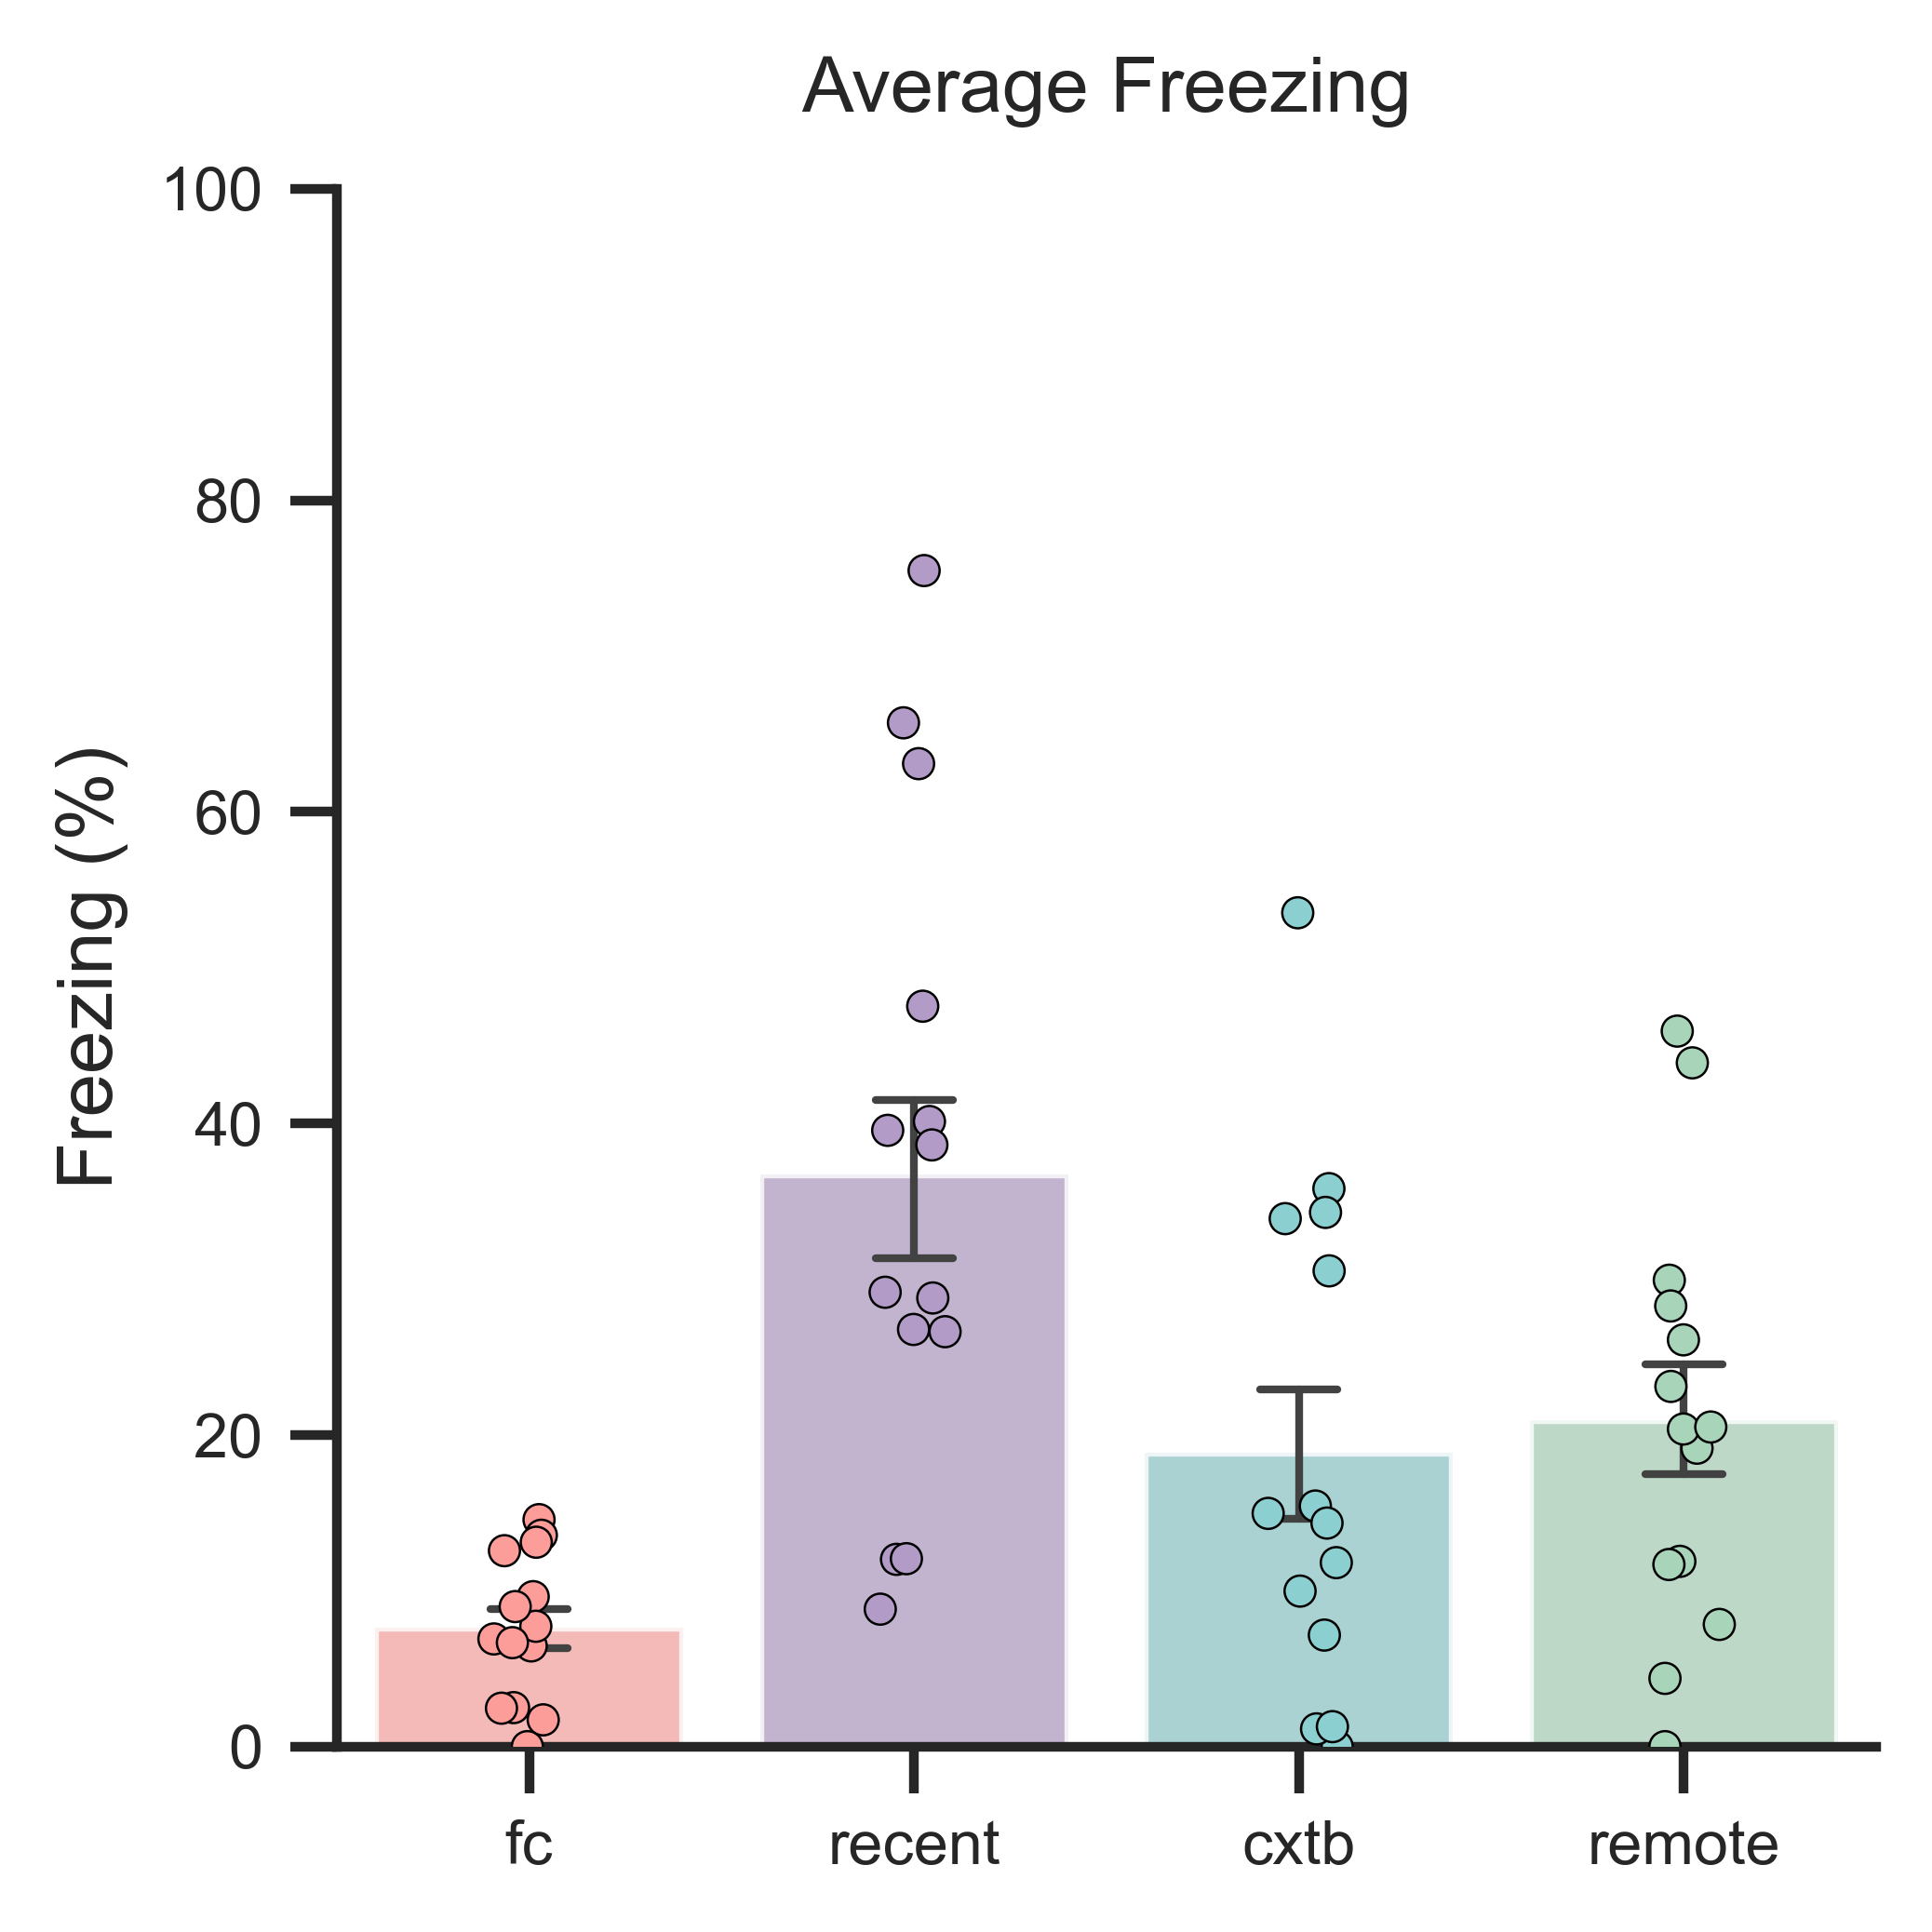

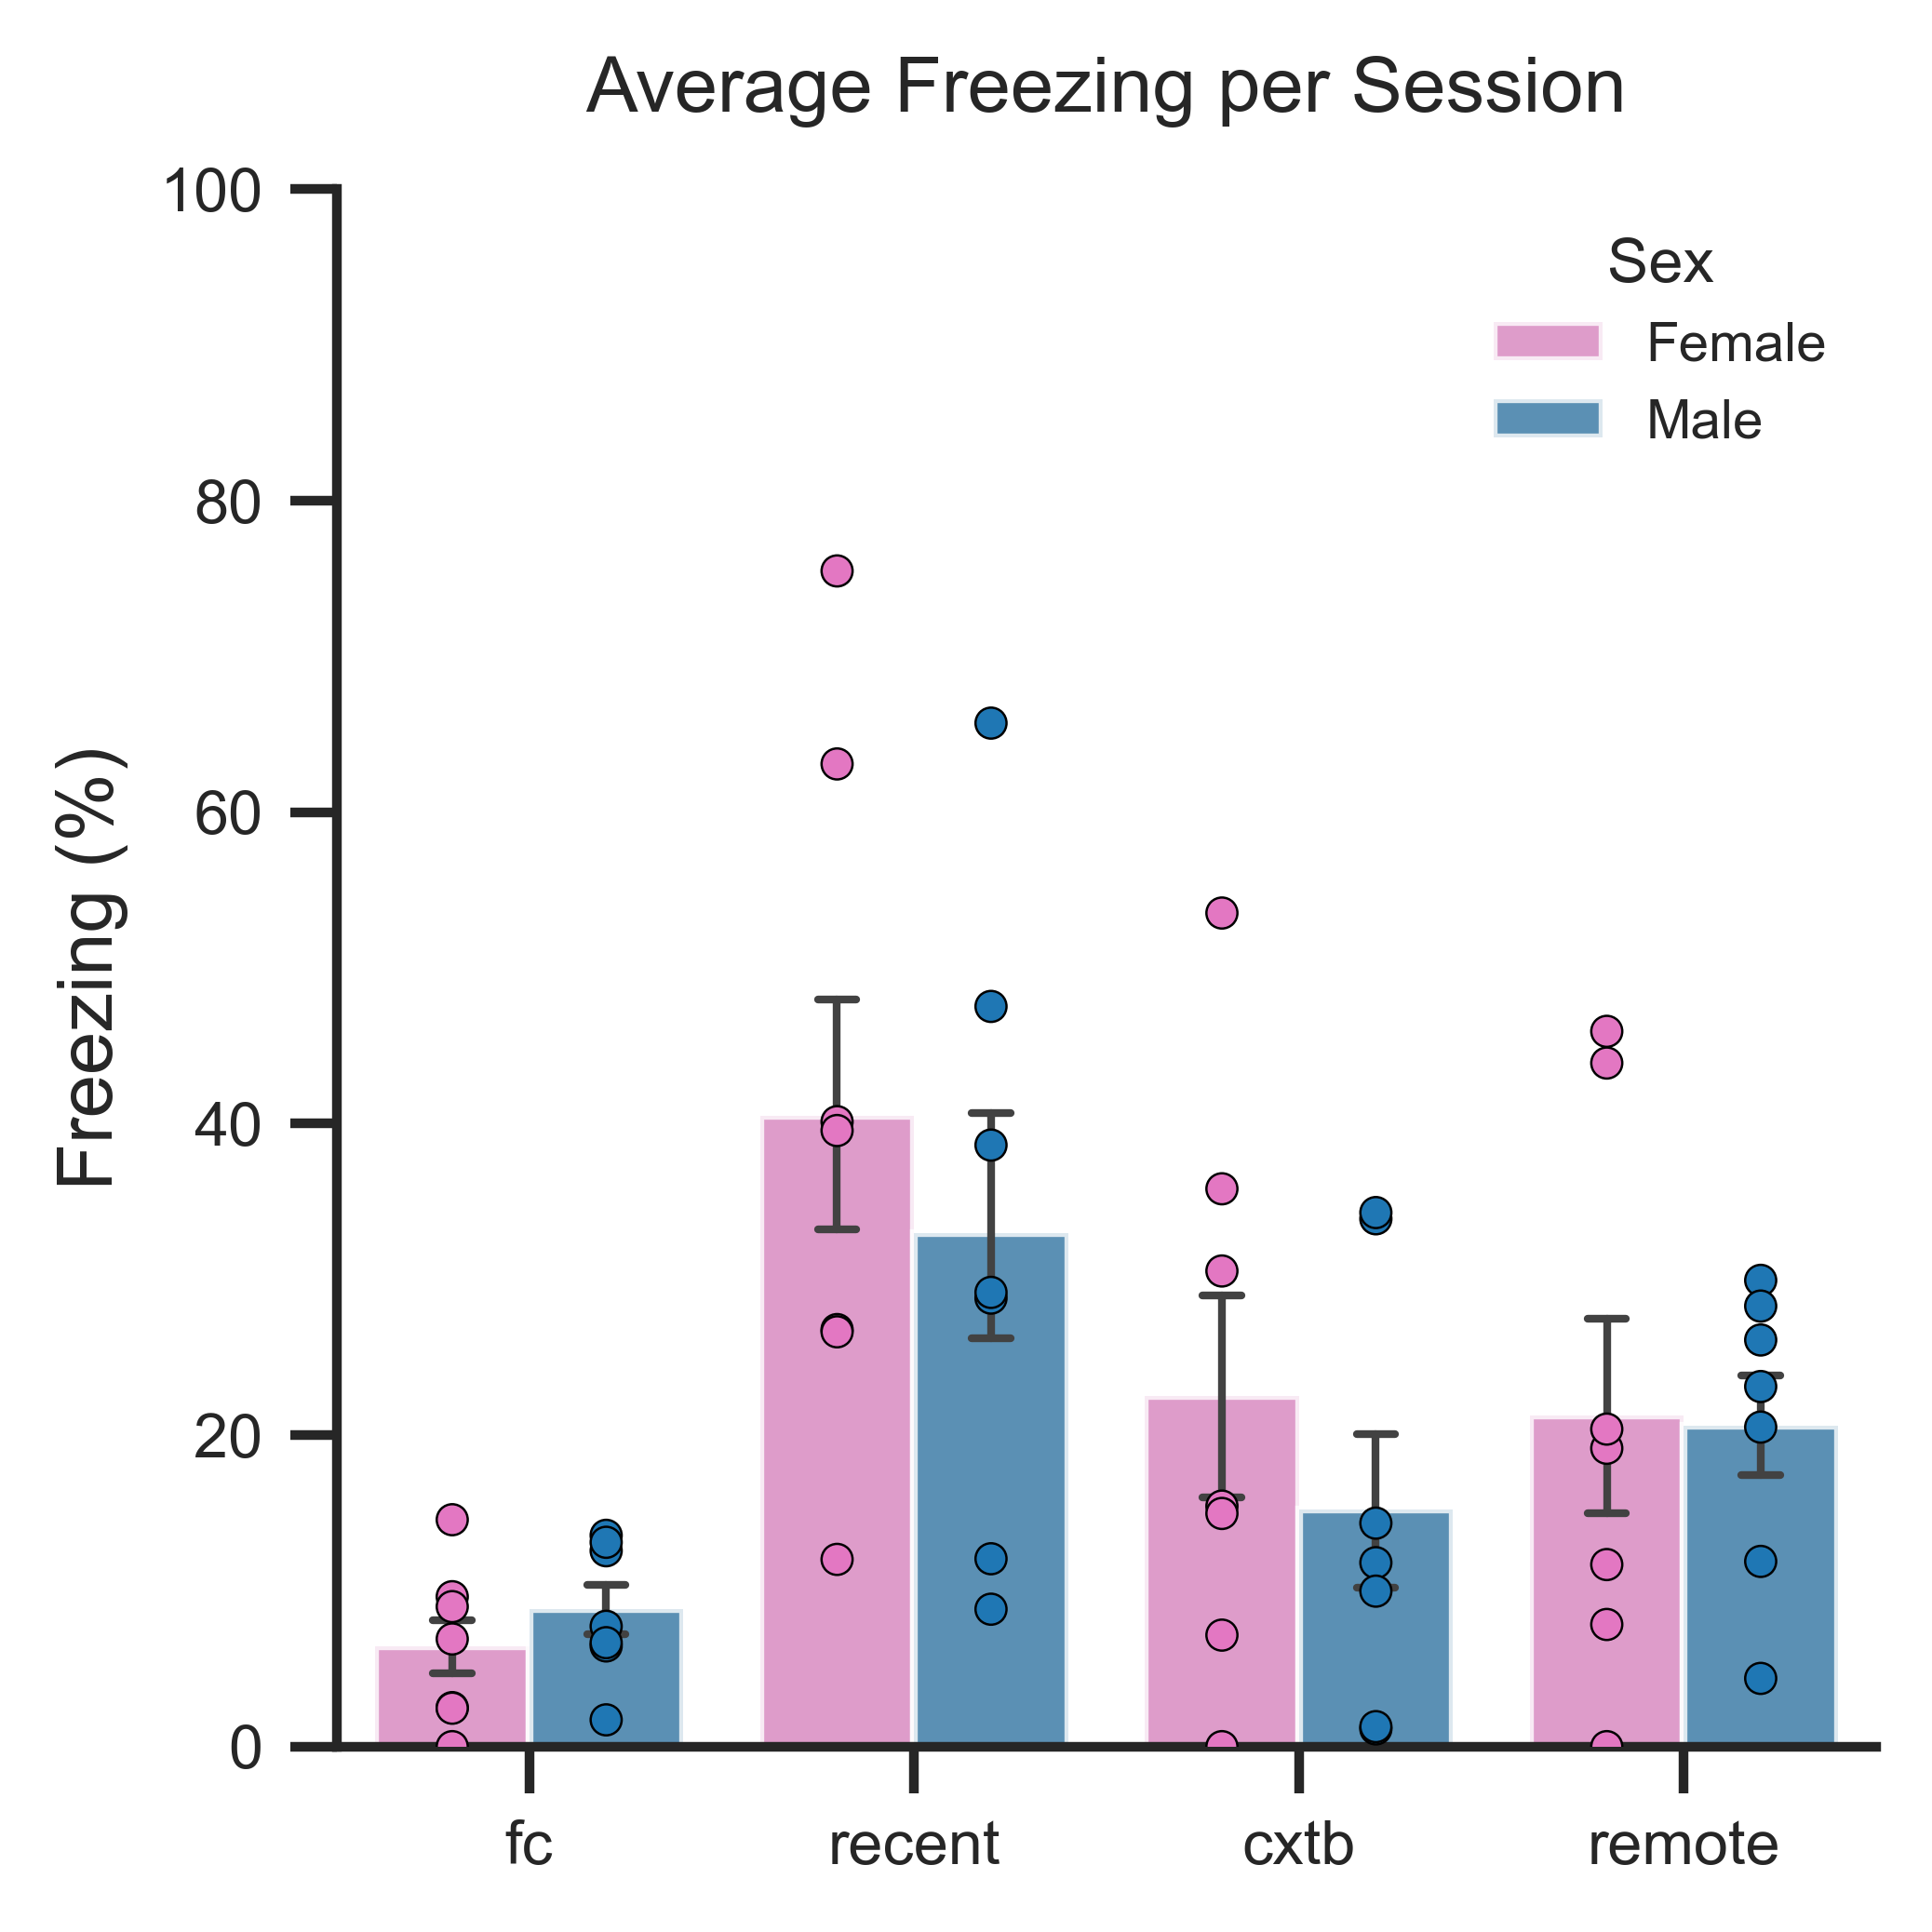

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: title={'center': 'Average Freezing per Session'}, ylabel='Freezing (%)'>)

In [4]:

order = ['fc', 'recent', 'cxtb', 'remote']

# Custom pastel color palette, keyed to THIS dataset's session names
session_colors = {
    'fc':     '#FC9D9A',   # Soft Coral
    'recent': '#B39BC8',   # Dusty Lavender
    'cxtb':   '#8CCFD0',   # Cool Sky Blue
    'remote': '#A8D5BA'    # Warm Taupe
}


#Average freezing per session (all mice, sexes pooled)
def plot_avg_freezing_all(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

    bar_colors = [session_colors[s] for s in order]

    sns.barplot(
        x='Session', y='freezing_percentage', data=df,
        order=order, errorbar=('ci', 68), capsize=.2, err_kws={'linewidth': 1},
        alpha=0.8, ax=ax, palette=bar_colors
    )

    sns.stripplot(
        x='Session', y='freezing_percentage', data=df,
        jitter=True, linewidth=0.3, edgecolor='black',
        size=4, order=order, ax=ax, palette=session_colors
    )

    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_ylabel('Freezing (%)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


#Average freezing per session, split by sex
def plot_avg_freezing_by_sex(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    colors = ["#e377c2", "#1f77b4"]  # Female, Male
    plt.rcParams.update({'font.size': 8, 'svg.fonttype': 'none'})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    sns.barplot(
        x='Session', y='freezing_percentage', hue='Sex', data=df,
        order=order,
        errorbar=('ci', 68), capsize=.2, err_kws={'linewidth': 1}, alpha=0.8, ax=ax
    )

    sns.stripplot(
        x='Session', y='freezing_percentage', hue='Sex', data=df,
        dodge=True, jitter=False, linewidth=0.3, edgecolor='black', size=4,
        order=order, ax=ax
    )

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Sex', loc='upper right',
              fontsize=7, title_fontsize=8, frameon=False)

    ax.set_ylabel('Freezing (%)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


# Run
plot_avg_freezing_all(
    df_avg_all,
    title="Average Freezing",
    save_path='/Users/suthardr/Desktop/Michelle B Data/allsessions_freezing_jitter.svg'
)

plot_avg_freezing_by_sex(
    df_avg_all,
    title="Average Freezing per Session",
    save_path='/Users/suthardr/Desktop/Michelle B Data/allsessions_freezing_bysex.svg'
)

In [6]:
import statsmodels.formula.api as smf

df = df_avg_all.copy()
df['Session'] = df['Session'].astype('category')
df['Mouse'] = df['Mouse'].astype('category')
df['Sex'] = df['Sex'].astype('category')

# Reorder Session categories to match plot order (fc = reference level)
df['Session'] = pd.Categorical(df['Session'], categories=order, ordered=False)

model_session = smf.mixedlm("freezing_percentage ~ Session", data=df, groups=df["Mouse"])
result_session = model_session.fit()
print(result_session.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: freezing_percentage
No. Observations: 56      Method:             REML               
No. Groups:       14      Scale:              125.6172           
Min. group size:  4       Log-Likelihood:     -213.8486          
Max. group size:  4       Converged:          Yes                
Mean group size:  4.0                                            
------------------------------------------------------------------
                    Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept            7.638     3.982  1.918  0.055  -0.166  15.443
Session[T.recent]   29.108     4.236  6.871  0.000  20.805  37.411
Session[T.cxtb]     11.235     4.236  2.652  0.008   2.932  19.537
Session[T.remote]   13.302     4.236  3.140  0.002   4.999  21.605
Group Var           96.367     5.163                              



In [10]:
#Pairwise comparisons between sessions (unpaired, Bonferroni-corrected)
import pingouin as pg

posthoc_between = pg.pairwise_tests(
    dv='freezing_percentage',
    between='Session',
    data=df,
    padjust='bonf',
    effsize='hedges'
)
print(posthoc_between[['A', 'B', 'T', 'p-unc', 'p-corr', 'hedges']])

        A       B         T     p-unc    p-corr    hedges
0      fc  recent -5.161072  0.000022  0.000132 -1.893885
1      fc    cxtb -2.500586  0.019032  0.114193 -0.917605
2      fc  remote -3.475727  0.001804  0.010824 -1.275438
3  recent    cxtb  2.559167  0.016658  0.099949  0.939101
4  recent  remote  2.403725  0.023654  0.141921  0.882061
5    cxtb  remote -0.367688  0.716082  1.000000 -0.134925


In [8]:
#Sex effect (mixed-effects model, random intercept for Mouse)
model_sex = smf.mixedlm("freezing_percentage ~ Sex", data=df, groups=df["Mouse"])
result_sex = model_sex.fit()
print(result_sex.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: freezing_percentage
No. Observations: 56      Method:             REML               
No. Groups:       14      Scale:              260.3117           
Min. group size:  4       Log-Likelihood:     -234.5171          
Max. group size:  4       Converged:          Yes                
Mean group size:  4.0                                            
-------------------------------------------------------------------
              Coef.    Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
Intercept     22.685      4.396    5.160   0.000    14.068   31.301
Sex[T.Male]   -3.270      6.217   -0.526   0.599   -15.456    8.916
Group Var     70.221      3.882                                    



In [9]:
#Combined Sex + Session model
model_full = smf.mixedlm("freezing_percentage ~ Sex + Session", data=df, groups=df["Mouse"]).fit()
print(model_full.summary())


              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: freezing_percentage
No. Observations: 56      Method:             REML               
No. Groups:       14      Scale:              125.6173           
Min. group size:  4       Log-Likelihood:     -210.9744          
Max. group size:  4       Converged:          Yes                
Mean group size:  4.0                                            
-----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------
Intercept              9.273    5.105  1.817 0.069  -0.732 19.278
Sex[T.Male]           -3.270    6.217 -0.526 0.599 -15.456  8.916
Session[T.recent]     29.108    4.236  6.871 0.000  20.805 37.411
Session[T.cxtb]       11.235    4.236  2.652 0.008   2.932 19.537
Session[T.remote]     13.302    4.236  3.140 0.002   4.999 21.605
Group Var            103

In [6]:
long_df

,Region,CellType,Session,ID,Peak_Times,Amplitudes,AUC,FWHM,Treatment
0,PL,astros,fc,F2,122.609024,32.996357,22.746964,0.888417,shock
1,PL,astros,fc,F2,182.469248,28.314221,18.269211,0.829753,shock
2,PL,astros,fc,F2,242.462816,26.161144,14.528306,0.715767,shock
3,PL,astros,fc,F2,302.156320,28.215170,19.905497,0.897848,shock
4,PL,astros,fc,F5,122.431136,103.743667,77.133996,0.910377,shock
...,...,...,...,...,...,...,...,...,...
6752,vCA1,neurons,remote,M18,106.899424,8.155188,6.684742,1.249873,no-shock
6753,vCA1,neurons,remote,M18,114.398624,4.579318,1.213386,0.551671,no-shock
6754,vCA1,neurons,remote,M18,125.030784,4.247124,3.303940,1.458627,no-shock
6755,vCA1,neurons,remote,M18,128.497088,3.909005,1.006964,0.388794,no-shock


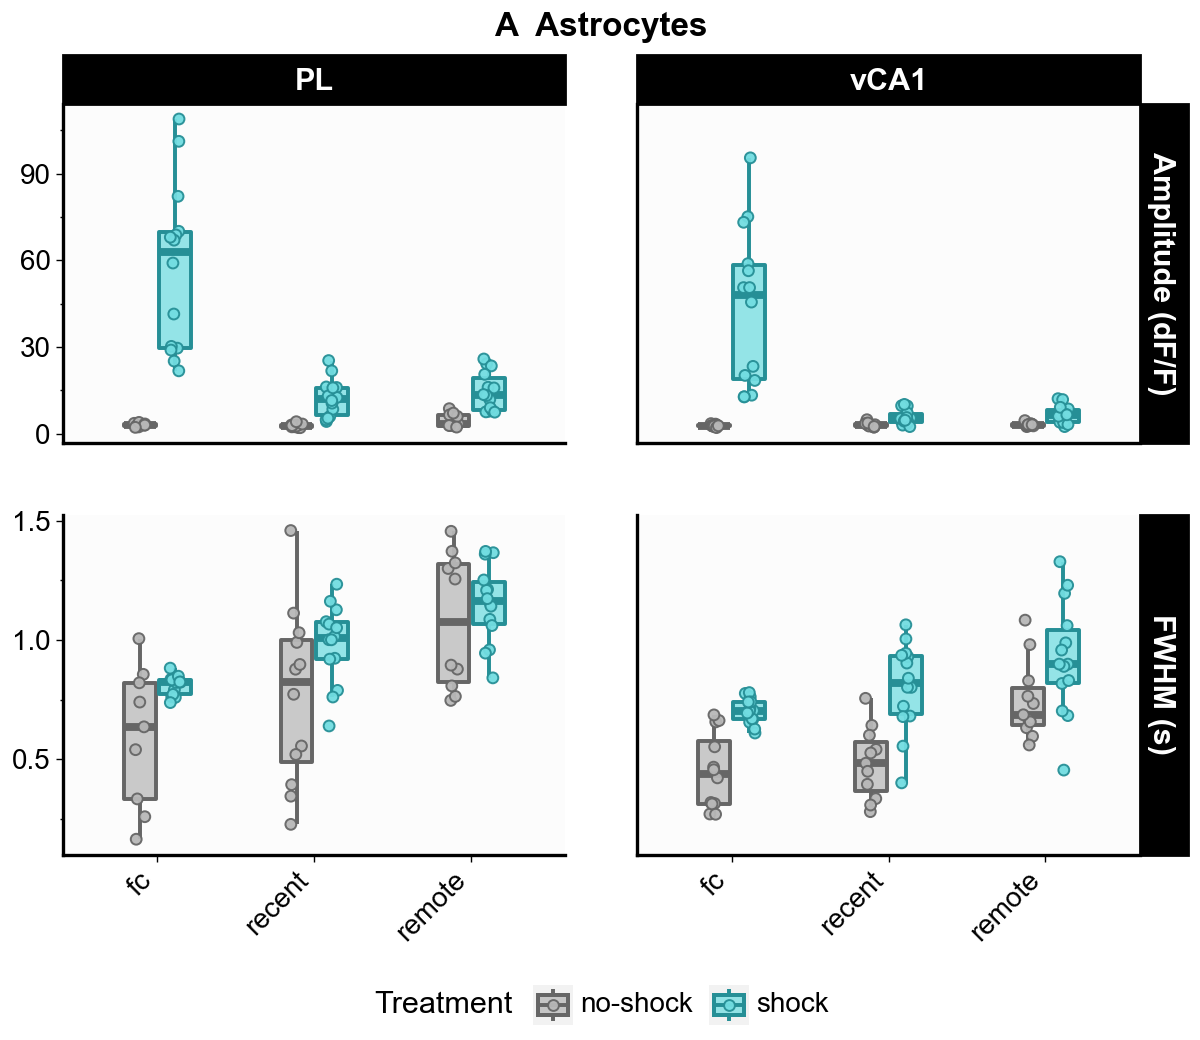

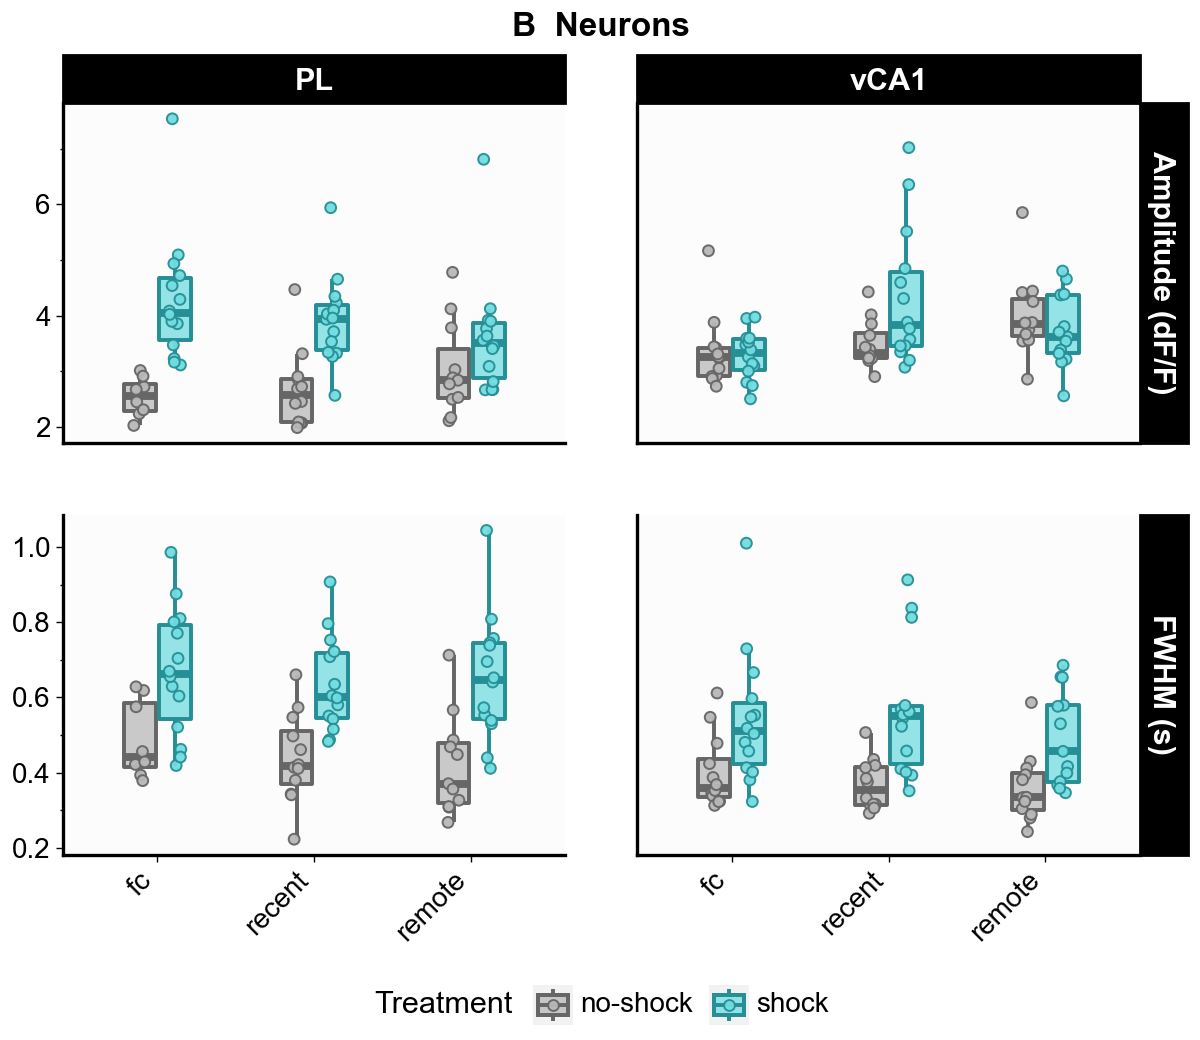

In [52]:
import pandas as pd
from plotnine import (
    ggplot, aes, geom_boxplot, geom_point, position_jitterdodge,
    facet_grid, theme_gray, theme, labs,
    scale_fill_manual, scale_color_manual,
    element_text, element_rect, element_line, element_blank
)

long_df = pd.read_csv(
    '/Users/suthardr/Desktop/Michelle B Data/pl_vca1_events_long.csv'
)
long_df.columns = long_df.columns.str.strip()

sessions = ['fc', 'recall', 'remote']
metrics = ['Amplitudes', 'FWHM']

# Light box fills
FILL_COLORS = {
    'no-shock': '#B8B8B8',
    'shock': '#72DDE1'
}

# Darker matching outlines, medians, whiskers, and dots
LINE_COLORS = {
    'no-shock': '#666666',
    'shock': '#268F96'
}

SESSION_LABELS = {
    'fc': 'fc',
    'recall': 'recent',
    'remote': 'remote'
}


def _base_theme(figsize):
    return theme(
        figure_size=figsize,
        panel_spacing=.06,
        legend_position='bottom',

        panel_background=element_rect(fill='#FCFCFC'),
        panel_border=element_blank(),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),

        axis_line_x=element_line(color='black', size=1.2),
        axis_line_y=element_line(color='black', size=1.2),

        strip_background=element_rect(fill='black', color='black'),
        strip_text=element_text(
            color='white',
            weight='bold',
            size=11
        ),

        axis_text=element_text(color='black', size=10),
        axis_text_x=element_text(
            rotation=45,
            hjust=1,
            size=10
        ),

        axis_title_y=element_text(color='black', size=11),
        axis_ticks=element_line(color='black', size=.5),

        legend_text=element_text(size=10),
        legend_title=element_text(size=11),

        plot_title=element_text(
            size=12,
            weight='bold'
        )
    )


def _prep(df):
    d = df[df['Session'].isin(sessions)].copy()

    d['Session'] = d['Session'].map(SESSION_LABELS)

    d['Session'] = pd.Categorical(
        d['Session'],
        categories=[SESSION_LABELS[s] for s in sessions],
        ordered=True
    )

    d['Region'] = pd.Categorical(
        d['Region'],
        categories=['PL', 'vCA1'],
        ordered=True
    )

    d['CellType'] = pd.Categorical(
        d['CellType'],
        categories=['astros', 'neurons'],
        ordered=True
    )

    d['Treatment'] = pd.Categorical(
        d['Treatment'],
        categories=['no-shock', 'shock'],
        ordered=True
    )

    d_avg = (
        d.groupby(
            ['Region', 'CellType', 'Session', 'Treatment', 'ID'],
            observed=True
        )[metrics]
        .mean()
        .reset_index()
    )

    return d_avg


def _single_celltype_grid(d_avg, cell_type, panel_letter):

    d = d_avg[
        d_avg['CellType'] == cell_type
    ].copy()

    d_long = d.melt(
        id_vars=[
            'Region',
            'Session',
            'Treatment',
            'ID'
        ],
        value_vars=metrics,
        var_name='metric',
        value_name='value'
    )

    metric_labels = {
        'Amplitudes': 'Amplitude (dF/F)',
        'FWHM': 'FWHM (s)'
    }

    d_long['metric'] = pd.Categorical(
        d_long['metric'].map(metric_labels),
        categories=[metric_labels[m] for m in metrics],
        ordered=True
    )

    p = (
        ggplot(
            d_long,
            aes(
                x='Session',
                y='value',
                fill='Treatment',
                color='Treatment'
            )
        )

        # Box fill = light treatment color
        # Box outline, whiskers, median = darker treatment color
        + geom_boxplot(
            width=.45,
            alpha=.75,
            outlier_shape=None,
            size=.8,
            position='dodge2'
        )

        + geom_point(
            aes(fill='Treatment', color='Treatment'),
            shape='o',
            size=1.8,
            stroke=0.4,
            alpha=.95,
            position=position_jitterdodge(
                jitter_width=.15,
                dodge_width=.45
            )
        )

        + facet_grid(
            'metric ~ Region',
            scales='free_y'
        )

        + scale_fill_manual(
            values=FILL_COLORS
        )

        + scale_color_manual(
            values=LINE_COLORS
        )

        + labs(
            x='',
            y='',
            fill='Treatment',
            color='Treatment',
            title=(
                f'{panel_letter}  '
                f'{"Astrocytes" if cell_type == "astros" else "Neurons"}'
            )
        )

        + theme_gray(
            base_family='Arial',
            base_size=10
        )

        + _base_theme((6, 5.2))
    )

    return p


def plot_compound_figure(
    df,
    save_path_astros=None,
    save_path_neurons=None
):

    d_avg = _prep(df)

    p_astros = _single_celltype_grid(
        d_avg,
        'astros',
        'A'
    )

    p_neurons = _single_celltype_grid(
        d_avg,
        'neurons',
        'B'
    )

    if save_path_astros:
        p_astros.save(
            save_path_astros,
            dpi=600,
            verbose=False
        )

    if save_path_neurons:
        p_neurons.save(
            save_path_neurons,
            dpi=600,
            verbose=False
        )

    return p_astros, p_neurons


p_astros, p_neurons = plot_compound_figure(
    long_df,
    save_path_astros=(
        '/Users/suthardr/Desktop/Michelle B Data/'
        'panel_astros.svg'
    ),
    save_path_neurons=(
        '/Users/suthardr/Desktop/Michelle B Data/'
        'panel_neurons.svg'
    )
)

display(p_astros)
display(p_neurons)

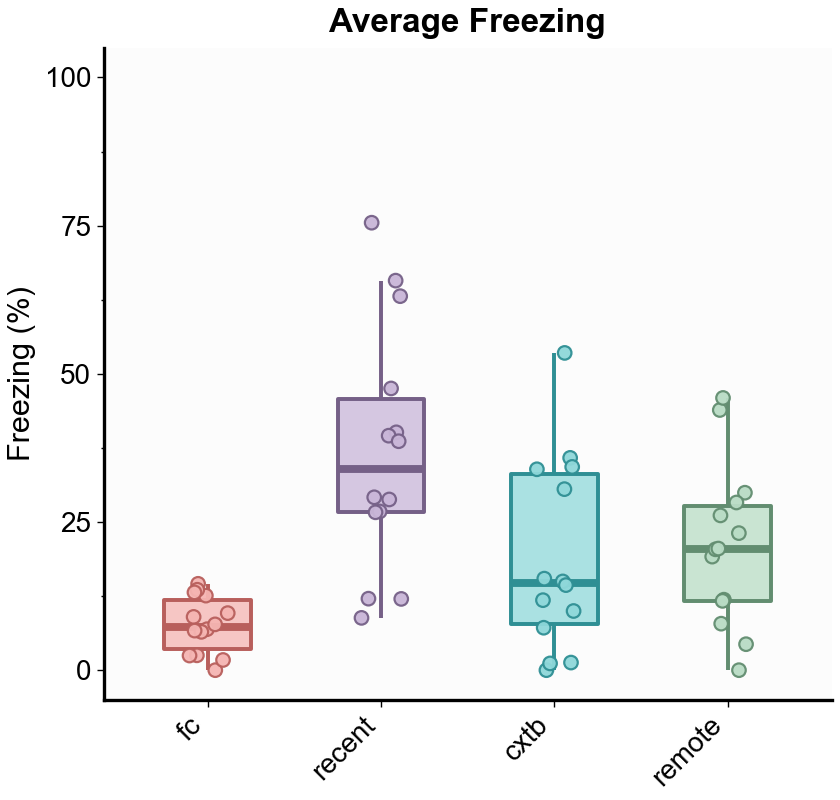

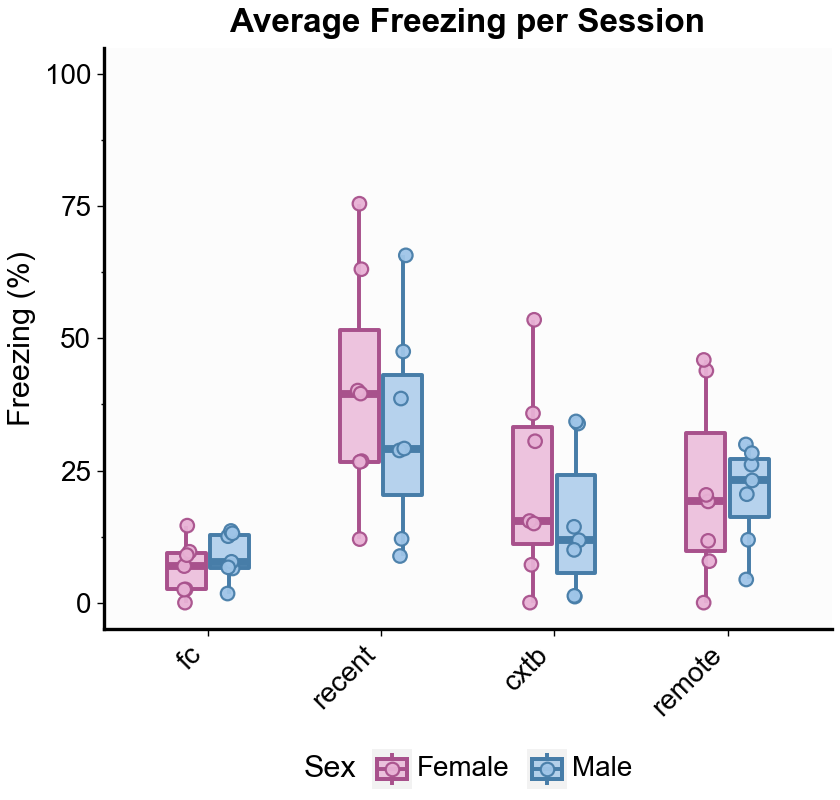

In [53]:
import pandas as pd
from plotnine import (
    ggplot, aes, geom_boxplot, geom_point,
    position_jitter, position_jitterdodge,
    theme_gray, theme, labs,
    scale_fill_manual, scale_color_manual,
    scale_y_continuous,
    element_text, element_rect, element_line, element_blank
)

df_avg_all = pd.read_csv(
    '/Users/suthardr/Desktop/Michelle B Data/behavior.csv'
)

order = ['fc', 'recent', 'cxtb', 'remote']

# Light fills
SESSION_FILL = {
    'fc': '#F5B5B2',
    'recent': '#C9B6D8',
    'cxtb': '#8FD8DA',
    'remote': '#B9DCC5'
}

# Darker matching outlines / dots
SESSION_LINE = {
    'fc': '#B85F5C',
    'recent': '#756087',
    'cxtb': '#2F8F94',
    'remote': '#628D70'
}

SEX_FILL = {
    'Female': '#E8B1D5',
    'Male': '#9FC5E8'
}

SEX_LINE = {
    'Female': '#A8518C',
    'Male': '#477DA8'
}


def behavior_theme(figsize=(4.2, 4.0)):
    return theme(
        figure_size=figsize,
        panel_background=element_rect(fill='#FCFCFC'),
        panel_border=element_blank(),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),

        axis_line_x=element_line(color='black', size=1.2),
        axis_line_y=element_line(color='black', size=1.2),
        axis_ticks=element_line(color='black', size=.5),

        axis_text=element_text(color='black', size=10),
        axis_text_x=element_text(rotation=45, hjust=1, size=10),
        axis_title_y=element_text(color='black', size=11),

        legend_position='bottom',
        legend_text=element_text(size=10),
        legend_title=element_text(size=11),

        plot_title=element_text(size=12, weight='bold')
    )


# ============================================================
# ALL MICE
# ============================================================

def plot_avg_freezing_all(df, title="", save_path=None):

    d = df.copy()

    d['Session'] = pd.Categorical(
        d['Session'],
        categories=order,
        ordered=True
    )

    p = (
        ggplot(
            d,
            aes(
                x='Session',
                y='freezing_percentage',
                fill='Session',
                color='Session'
            )
        )

        + geom_boxplot(
            width=.5,
            alpha=.75,
            outlier_shape=None,
            size=.8
        )

        + geom_point(
            shape='o',
            size=2.3,
            stroke=.45,
            alpha=.95,
            position=position_jitter(width=.12, height=0)
        )

        + scale_fill_manual(values=SESSION_FILL)
        + scale_color_manual(values=SESSION_LINE)

        + scale_y_continuous(
            limits=(0, 100)
        )

        + labs(
            x='',
            y='Freezing (%)',
            title=title
        )

        + theme_gray(
            base_family='Arial',
            base_size=10
        )

        + behavior_theme((4.2, 4.0))

        + theme(
            legend_position='none'
        )
    )

    if save_path:
        p.save(
            save_path,
            width=4.2,
            height=4.0,
            units='in',
            dpi=600,
            verbose=False
        )

    return p


# ============================================================
# SPLIT BY SEX
# ============================================================

def plot_avg_freezing_by_sex(df, title="", save_path=None):

    d = df.copy()

    d['Session'] = pd.Categorical(
        d['Session'],
        categories=order,
        ordered=True
    )

    d['Sex'] = pd.Categorical(
        d['Sex'],
        categories=['Female', 'Male'],
        ordered=True
    )

    p = (
        ggplot(
            d,
            aes(
                x='Session',
                y='freezing_percentage',
                fill='Sex',
                color='Sex'
            )
        )

        + geom_boxplot(
            width=.5,
            alpha=.75,
            outlier_shape=None,
            size=.8,
            position='dodge2'
        )

        + geom_point(
            shape='o',
            size=2.3,
            stroke=.45,
            alpha=.95,
            position=position_jitterdodge(
                jitter_width=.08,
                dodge_width=.5
            )
        )

        + scale_fill_manual(values=SEX_FILL)
        + scale_color_manual(values=SEX_LINE)

        + scale_y_continuous(
            limits=(0, 100)
        )

        + labs(
            x='',
            y='Freezing (%)',
            fill='Sex',
            color='Sex',
            title=title
        )

        + theme_gray(
            base_family='Arial',
            base_size=10
        )

        + behavior_theme((4.2, 4.0))
    )

    if save_path:
        p.save(
            save_path,
            width=4.2,
            height=4.0,
            units='in',
            dpi=600,
            verbose=False
        )

    return p


# ============================================================
# RUN
# ============================================================

p_freezing_all = plot_avg_freezing_all(
    df_avg_all,
    title='Average Freezing',
    save_path='/Users/suthardr/Desktop/Michelle B Data/allsessions_freezing_boxplot.svg'
)

p_freezing_sex = plot_avg_freezing_by_sex(
    df_avg_all,
    title='Average Freezing per Session',
    save_path='/Users/suthardr/Desktop/Michelle B Data/allsessions_freezing_bysex_boxplot.svg'
)

display(p_freezing_all)
display(p_freezing_sex)

In [54]:
# ============================================================
# FREEZING: SHOCK vs NO-SHOCK ACROSS SESSIONS
# ============================================================

TREATMENT_FILL = {
    'no-shock': '#B8B8B8',
    'shock': '#72DDE1'
}

TREATMENT_LINE = {
    'no-shock': '#666666',
    'shock': '#268F96'
}


def plot_avg_freezing_all(df, title="", save_path=None):

    d = df.copy()

    d['Session'] = pd.Categorical(
        d['Session'],
        categories=order,
        ordered=True
    )

    d['Treatment'] = pd.Categorical(
        d['Treatment'],
        categories=['no-shock', 'shock'],
        ordered=True
    )

    p = (
        ggplot(
            d,
            aes(
                x='Session',
                y='freezing_percentage',
                fill='Treatment',
                color='Treatment'
            )
        )

        # Shock and no-shock boxplots side-by-side
        + geom_boxplot(
            width=.48,
            alpha=.75,
            outlier_shape=None,
            size=.8,
            position='dodge2'
        )

        # Individual mice
        + geom_point(
            shape='o',
            size=2.3,
            stroke=.45,
            alpha=.95,
            position=position_jitterdodge(
                jitter_width=.10,
                dodge_width=.48
            )
        )

        + scale_fill_manual(values=TREATMENT_FILL)
        + scale_color_manual(values=TREATMENT_LINE)

        + scale_y_continuous(
            limits=(0, 100)
        )

        + labs(
            x='',
            y='Freezing (%)',
            fill='Treatment',
            color='Treatment',
            title=title
        )

        + theme_gray(
            base_family='Arial',
            base_size=10
        )

        + behavior_theme((4.5, 4.0))
    )

    if save_path:
        p.save(
            save_path,
            width=4.5,
            height=4.0,
            units='in',
            dpi=600,
            verbose=False
        )

    return p

In [55]:
p_freezing_all = plot_avg_freezing_all(
    df_avg_all,
    title='Average Freezing',
    save_path=(
        '/Users/suthardr/Desktop/Michelle B Data/'
        'allsessions_freezing_shock_vs_noshock.svg'
    )
)

display(p_freezing_all)

KeyError: 'Treatment'